In [ ]:
""" Using this notebook to conduct eda and validate pca pipeline

will:

- Setup and Load data
- do some basic eda, visualize data
- pca on healthy wells
- zca whitening
- visualize / sanity check that it works

"""

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df = pd.read_csv("all_profiles.csv")
print(df.shape)
df.head()

(504, 2144)


,plate_name,Row,Column,compound,dose_uM,cell_type,condition,Plane,Timepoint,Number of Analyzed Fields,...,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Valley 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Saddle 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Bright 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Dark 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Correlation 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Contrast 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Sum Variance 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Homogeneity 2 px - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Gabor Min 2 px w2 - Median per Well,Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Gabor Max 2 px w2 - Median per Well
0,AH_20250605_CP_PlateA1,2,2,SC79,16.0,WT/MT,treatment,1,1,9,...,0.005355,0.007229,0.008682,0.005869,0.760312,0.017898,0.035486,0.424393,0.000270,0.001924
1,AH_20250605_CP_PlateA1,2,3,SC79,8.0,WT/MT,treatment,1,1,9,...,0.005376,0.007480,0.007892,0.006029,0.737781,0.018478,0.034142,0.427044,0.000277,0.001968
2,AH_20250605_CP_PlateA1,2,4,SC79,4.0,WT/MT,treatment,1,1,9,...,0.006174,0.008324,0.008244,0.006786,0.712576,0.020753,0.032967,0.410220,0.000280,0.001977
3,AH_20250605_CP_PlateA1,2,5,SC79,2.0,WT/MT,treatment,1,1,9,...,0.006477,0.008287,0.008252,0.007331,0.697354,0.023220,0.032044,0.405050,0.000289,0.002051
4,AH_20250605_CP_PlateA1,2,6,SC79,1.0,WT/MT,treatment,1,1,9,...,0.007077,0.009134,0.006992,0.007912,0.703025,0.021041,0.035487,0.420186,0.000294,0.002083


In [3]:
df.columns

Index(['plate_name', 'Row', 'Column', 'compound', 'dose_uM', 'cell_type',
       'condition', 'Plane', 'Timepoint', 'Number of Analyzed Fields',
       ...
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Valley 2 px - Median per Well',
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Saddle 2 px - Median per Well',
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Bright 2 px - Median per Well',
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain SER Dark 2 px - Median per Well',
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Correlation 2 px - Median per Well',
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Contrast 2 px - Median per Well',
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Sum Variance 2 px - Median per Well',
       'Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Haralick Homogeneity 2 px - Median per

In [5]:
# seperate metadata and features

metadata_cols = df.columns[:13]
feature_cols = df.columns[13:]

healthy = df[df["condition"] == "healthy"]
healthy_features = healthy[feature_cols].values  # shape: (n_healthy_wells, ~2100)

print(f"Healthy wells: {healthy_features.shape[0]}")
print(f"Features: {healthy_features.shape[1]}")
print(df["condition"].value_counts())

Healthy wells: 108
Features: 2131
condition
treatment    288
disease      108
healthy      108
Name: count, dtype: int64


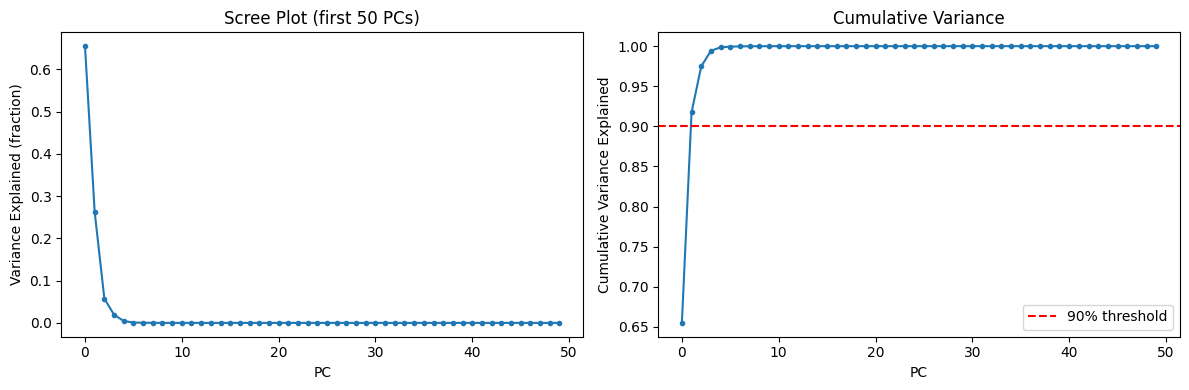

PCs needed for 90% variance: 2


In [8]:
from sklearn.decomposition import PCA

# center and fit PCA on healthy wells only
pca = PCA()  # fit all components first so we can look at the full scree plot
pca.fit(healthy_features)

# scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(pca.explained_variance_ratio_[:50], marker='o', markersize=3)
axes[0].set_xlabel("PC")
axes[0].set_ylabel("Variance Explained (fraction)")
axes[0].set_title("Scree Plot (first 50 PCs)")

axes[1].plot(np.cumsum(pca.explained_variance_ratio_[:50]), marker='o', markersize=3)
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
axes[1].set_xlabel("PC")
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].set_title("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_pcs = np.argmax(cumvar >= 0.9) + 1
print(f"PCs needed for 90% variance: {n_pcs}")

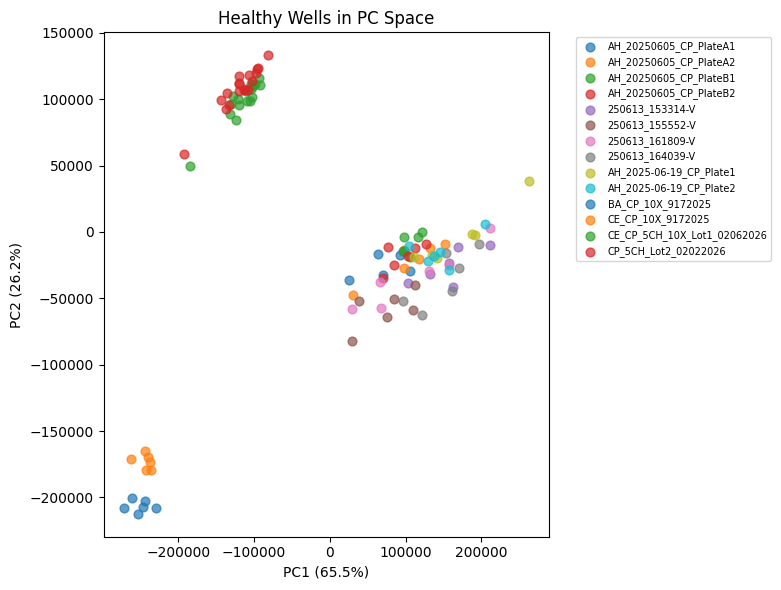

In [17]:
# project healthy wells into PC space
healthy_pcs = pca.transform(healthy_features)

# color by plate
plt.figure(figsize=(8, 6))
for plate in healthy["plate_name"].unique():
    mask = healthy["plate_name"].values == plate
    plt.scatter(healthy_pcs[mask, 0], healthy_pcs[mask, 1], 
                label=plate, alpha=0.7, s=40)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=7)
plt.title("Healthy Wells in PC Space")
plt.tight_layout()
plt.show()

In [15]:
# batch effects dominate, pca is just capturing what plate they come from, we can wait till team A takes care of batch effects

# for now, lets run the pca-zca whitening on a single plate to see if it turns out how we expect

healthy["plate_name"].value_counts()

plate_name
CE_CP_5CH_10X_Lot1_02062026    18
CP_5CH_Lot2_02022026           18
AH_20250605_CP_PlateA1          6
AH_20250605_CP_PlateA2          6
AH_20250605_CP_PlateB1          6
AH_20250605_CP_PlateB2          6
250613_153314-V                 6
250613_155552-V                 6
250613_161809-V                 6
250613_164039-V                 6
AH_2025-06-19_CP_Plate1         6
AH_2025-06-19_CP_Plate2         6
BA_CP_10X_9172025               6
CE_CP_10X_9172025               6
Name: count, dtype: int64

Healthy wells on this plate: 18
Features: 2131


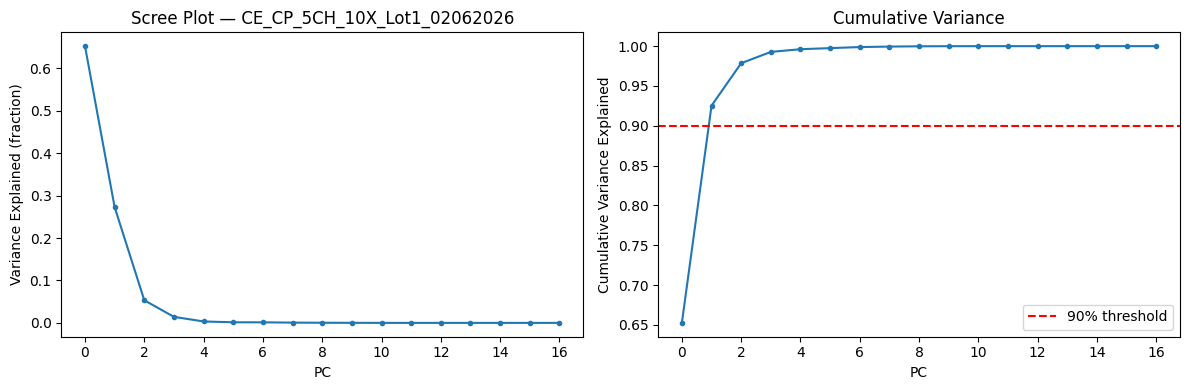

PCs needed for 90% variance: 2


In [18]:
# run eda on 1 plate since batch effects dominate the dataset
plate_id = "CE_CP_5CH_10X_Lot1_02062026"
plate_df = df[df["plate_name"] == plate_id]

plate_healthy = plate_df[plate_df["condition"] == "healthy"]
plate_healthy_features = plate_healthy[feature_cols].values

print(f"Healthy wells on this plate: {plate_healthy_features.shape[0]}")
print(f"Features: {plate_healthy_features.shape[1]}")

# fit pca on this plate's healthy wells
pca_plate = PCA()
pca_plate.fit(plate_healthy_features)

# scree plot again
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(17, plate_healthy_features.shape[0] - 1)

axes[0].plot(pca_plate.explained_variance_ratio_[:n_show], marker='o', markersize=3)
axes[0].set_xlabel("PC")
axes[0].set_ylabel("Variance Explained (fraction)")
axes[0].set_title(f"Scree Plot — {plate_id}")

axes[1].plot(np.cumsum(pca_plate.explained_variance_ratio_[:n_show]), marker='o', markersize=3)
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% threshold')
axes[1].set_xlabel("PC")
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].set_title("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

cumvar = np.cumsum(pca_plate.explained_variance_ratio_)
n_pcs = np.argmax(cumvar >= 0.9) + 1
print(f"PCs needed for 90% variance: {n_pcs}")

In [19]:
# whiten the data:
n_pcs = 2

# Project healthy wells into PC space
healthy_pcs = pca_plate.transform(plate_healthy_features)[:, :n_pcs]

# Compute whitening
healthy_std = healthy_pcs.std(axis=0)  # std along each PC
print(f"Healthy std per PC before whitening: {healthy_std}")

# Whiten
healthy_whitened = healthy_pcs / healthy_std
print(f"Healthy std per PC after whitening: {healthy_whitened.std(axis=0)}")

Healthy std per PC before whitening: [28048.7348342  18136.16801574]
Healthy std per PC after whitening: [1. 1.]


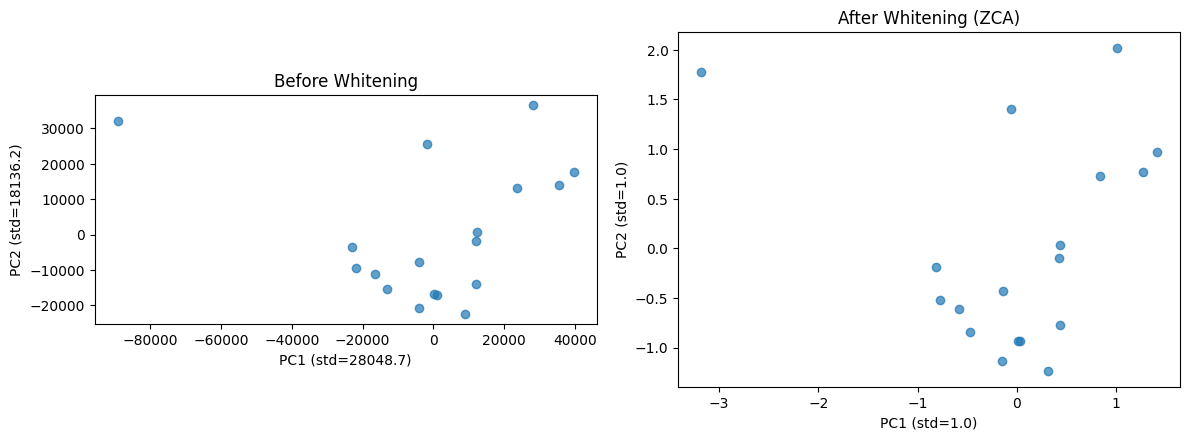

In [20]:
# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# before whitening
axes[0].scatter(healthy_pcs[:, 0], healthy_pcs[:, 1], alpha=0.7)
axes[0].set_xlabel(f"PC1 (std={healthy_std[0]:.1f})")
axes[0].set_ylabel(f"PC2 (std={healthy_std[1]:.1f})")
axes[0].set_title("Before Whitening")
axes[0].set_aspect('equal')

# after whitening
axes[1].scatter(healthy_whitened[:, 0], healthy_whitened[:, 1], alpha=0.7)
axes[1].set_xlabel(f"PC1 (std=1.0)")
axes[1].set_ylabel(f"PC2 (std=1.0)")
axes[1].set_title("After Whitening (ZCA)")
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
# seems to be working, notice axis scaled down...
# outlier in top left corner, note it

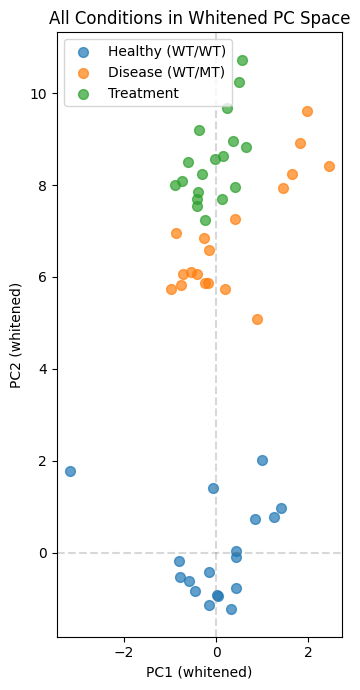

In [21]:
# apply loadings to all conditions

# get disease and treatment wells from this plate
plate_disease = plate_df[plate_df["condition"] == "disease"]
plate_treatment = plate_df[~plate_df["condition"].isin(["healthy", "disease"])]

# project into PCA space using healthy-fitted PCA
disease_pcs = pca_plate.transform(plate_disease[feature_cols].values)[:, :n_pcs]
treatment_pcs = pca_plate.transform(plate_treatment[feature_cols].values)[:, :n_pcs]

# whiten using healthy-fitted stds
disease_whitened = disease_pcs / healthy_std
treatment_whitened = treatment_pcs / healthy_std

# plot all three conditions
plt.figure(figsize=(8, 7))
plt.scatter(healthy_whitened[:, 0], healthy_whitened[:, 1], 
            label="Healthy (WT/WT)", alpha=0.7, s=50)
plt.scatter(disease_whitened[:, 0], disease_whitened[:, 1], 
            label="Disease (WT/MT)", alpha=0.7, s=50)
plt.scatter(treatment_whitened[:, 0], treatment_whitened[:, 1], 
            label="Treatment", alpha=0.7, s=50)
plt.xlabel("PC1 (whitened)")
plt.ylabel("PC2 (whitened)")
plt.title("All Conditions in Whitened PC Space")
plt.legend()
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
'''
interesting results, treated cells are further away from healthy than the diseased cells are, maybe the treatment just didn't work here...
could also be due to not having the data be preprocessed, PCs could just be dominated by a set of super-correlated features
meaning our PCA space isn't accurate...
'''